In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91762\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91762\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91762\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
df_train = pd.read_csv('../data/cleaned_train.csv')
df = df_train.copy()
print(f"Shape: {df_train.shape}")
df_train.head()

Shape: (6827, 9)


,id,text,anger,fear,joy,sadness,surprise,emotions,clean_text
0,0,the dentist that did the work apparently did a...,1,0,0,1,0,['anger' 'sadness'],the dentist that did the work apparently did a...
1,1,i'm gonna absolutely ~~suck~~ be terrible duri...,0,1,0,1,0,['fear' 'sadness'],i am going to absolutely be terrible during my...
2,2,"bridge: so leave me drowning calling houston, ...",0,1,0,1,0,['fear' 'sadness'],bridge so leave me drowning calling houston an...
3,3,after that mess i went to see my now ex-girlfr...,1,1,0,1,0,['anger' 'fear' 'sadness'],after that mess i went to see my now exgirlfri...
4,4,"as he stumbled i ran off, afraid it might some...",0,1,0,0,0,['fear'],as he stumbled i ran off afraid it might someh...


In [3]:
df_test = pd.read_csv('../data/cleaned_test.csv')
print(f"Shape: {df_test.shape}")
df_test.head()

Shape: (1707, 3)


,id,text,clean_text
0,0,she wanted to fight over every single little t...,she wanted to fight over every single little t...
1,1,"anyway, back to tuesday.",anyway back to tuesday
2,2,she shrieked at the dog to go back.,she shrieked at the dog to go back
3,3,yelling for everyone to get back or get inside...,yelling for everyone to get back or get inside...
4,4,still kind of freaky.,still kind of freaky


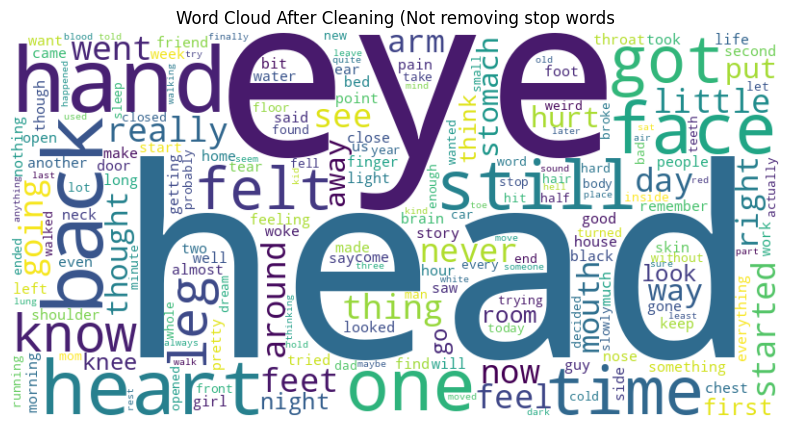

In [4]:
raw_text = ' '.join(df['clean_text'])
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud After Cleaning (Not removing stop words')
plt.show()

In [5]:
df.head()

,id,text,anger,fear,joy,sadness,surprise,emotions,clean_text
0,0,the dentist that did the work apparently did a...,1,0,0,1,0,['anger' 'sadness'],the dentist that did the work apparently did a...
1,1,i'm gonna absolutely ~~suck~~ be terrible duri...,0,1,0,1,0,['fear' 'sadness'],i am going to absolutely be terrible during my...
2,2,"bridge: so leave me drowning calling houston, ...",0,1,0,1,0,['fear' 'sadness'],bridge so leave me drowning calling houston an...
3,3,after that mess i went to see my now ex-girlfr...,1,1,0,1,0,['anger' 'fear' 'sadness'],after that mess i went to see my now exgirlfri...
4,4,"as he stumbled i ran off, afraid it might some...",0,1,0,0,0,['fear'],as he stumbled i ran off afraid it might someh...


# Baseline Model 1 (Not removing stop words and no Lemmatization)

In [6]:
emotion_cols = ['anger', 'fear', 'joy', 'sadness', 'surprise']

X = df['clean_text']
y = df[emotion_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

Training set size: 5461
Validation set size: 1366


In [7]:
vectorizer = TfidfVectorizer(max_features=5000) # Can use Count Vectorizer also
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [8]:
logreg = LogisticRegression(solver='sag', random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_train_tfidf, y_train)

,estimator,LogisticRegre... solver='sag')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [9]:
y_pred = ovr_classifier.predict(X_val_tfidf)
macro_f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
print(f"\nValidation Macro F1-score: {macro_f1:.4f}")


Validation Macro F1-score: 0.4307


## For test dataset

In [10]:
df_t = df_test.copy()
X_test = df_t['clean_text']
X_tfidf = vectorizer.fit_transform(X)
X_test_tfidf = vectorizer.transform(X_test)

In [11]:
logreg = LogisticRegression(solver='sag', random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_tfidf, y)

,estimator,LogisticRegre... solver='sag')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [12]:
y_test_pred = ovr_classifier.predict(X_test_tfidf)
sub = pd.DataFrame(y_test_pred, columns=['anger', 'fear', 'joy', 'sadness', 'surprise'])

sub['id'] = range(len(y_test_pred))
sub = sub[['id', 'anger', 'fear', 'joy', 'sadness', 'surprise']]
sub.head()
# sub.to_csv('submission.csv', index=False)

,id,anger,fear,joy,sadness,surprise
0,0,0,0,0,0,0
1,1,0,0,0,0,0
2,2,0,1,0,0,0
3,3,0,1,0,0,0
4,4,0,1,0,0,1


In [13]:
sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        1707 non-null   int64
 1   anger     1707 non-null   int64
 2   fear      1707 non-null   int64
 3   joy       1707 non-null   int64
 4   sadness   1707 non-null   int64
 5   surprise  1707 non-null   int64
dtypes: int64(6)
memory usage: 80.1 KB


# Baseline Model 2 (Removing stop words and no Lemmatization)

In [20]:
emotion_cols = ['anger', 'fear', 'joy', 'sadness', 'surprise']

X = df['clean_text']
y = df[emotion_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

Training set size: 5461
Validation set size: 1366


In [23]:
stop_words_list = stopwords.words('english')
negation_words = {'not', 'no', 'never', 'nor', 'neither', 'ain', 'aren', "aren't", 'couldn', "couldn't", 
                  'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', 
                  "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', 
                  "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', 
                  "weren't", 'won', "won't", 'wouldn', "wouldn't"}

custom_stop_words = set(stop_words_list) - negation_words

In [25]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words=list(custom_stop_words)) # Can use Count Vectorizer also
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [26]:
logreg = LogisticRegression(solver='sag', random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_train_tfidf, y_train)

,estimator,LogisticRegre... solver='sag')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [27]:
y_pred = ovr_classifier.predict(X_val_tfidf)
macro_f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
print(f"\nValidation Macro F1-score: {macro_f1:.4f}")


Validation Macro F1-score: 0.4171


## For test dataset

In [29]:
df_t = df_test.copy()
X_test = df_t['clean_text']
X_tfidf = vectorizer.fit_transform(X)
X_test_tfidf = vectorizer.transform(X_test)

In [30]:
logreg = LogisticRegression(solver='sag', random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_tfidf, y)

,estimator,LogisticRegre... solver='sag')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [31]:
y_test_pred = ovr_classifier.predict(X_test_tfidf)
sub = pd.DataFrame(y_test_pred, columns=['anger', 'fear', 'joy', 'sadness', 'surprise'])

sub['id'] = range(len(y_test_pred))
sub = sub[['id', 'anger', 'fear', 'joy', 'sadness', 'surprise']]
sub.head()
# sub.to_csv('submission.csv', index=False)

,id,anger,fear,joy,sadness,surprise
0,0,0,0,0,0,0
1,1,0,0,0,0,0
2,2,0,1,0,0,0
3,3,0,1,0,0,0
4,4,0,1,0,0,1


# Baseline Model 3 (Not removing Stop Words but performing Lemmatization)

In [33]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_output = ' '.join([lemmatizer.lemmatize(w) for w in words])
    return lemmatized_output
    
df['lemmatized_text'] = df['clean_text'].apply(lemmatize_text)

In [34]:
emotion_cols = ['anger', 'fear', 'joy', 'sadness', 'surprise']

X = df['lemmatized_text']
y = df[emotion_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

Training set size: 5461
Validation set size: 1366


In [35]:
vectorizer = TfidfVectorizer(max_features=5000) # Can use Count Vectorizer also
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [36]:
logreg = LogisticRegression(solver='sag', random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_train_tfidf, y_train)

,estimator,LogisticRegre... solver='sag')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [37]:
y_pred = ovr_classifier.predict(X_val_tfidf)
macro_f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
print(f"\nValidation Macro F1-score: {macro_f1:.4f}")


Validation Macro F1-score: 0.4358


## For test dataset

In [38]:
df_t = df_test.copy()
df_t['lemmatized_text'] = df_t['clean_text'].apply(lemmatize_text)
X_test = df_t['lemmatized_text']
X_tfidf = vectorizer.fit_transform(X)
X_test_tfidf = vectorizer.transform(X_test)

In [39]:
logreg = LogisticRegression(solver='sag', random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_tfidf, y)

,estimator,LogisticRegre... solver='sag')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [40]:
y_test_pred = ovr_classifier.predict(X_test_tfidf)
sub = pd.DataFrame(y_test_pred, columns=['anger', 'fear', 'joy', 'sadness', 'surprise'])

sub['id'] = range(len(y_test_pred))
sub = sub[['id', 'anger', 'fear', 'joy', 'sadness', 'surprise']]
sub.head()
# sub.to_csv('submission.csv', index=False)

,id,anger,fear,joy,sadness,surprise
0,0,0,1,0,0,0
1,1,0,0,0,0,0
2,2,0,1,0,0,0
3,3,0,1,0,0,0
4,4,0,1,0,0,1


# Baseline Model 4 (Removing Stop Words and performing Lemmatization)

In [41]:
emotion_cols = ['anger', 'fear', 'joy', 'sadness', 'surprise']

X = df['lemmatized_text']
y = df[emotion_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

Training set size: 5461
Validation set size: 1366


In [42]:
stop_words_list = stopwords.words('english')
negation_words = {'not', 'no', 'never', 'nor', 'neither', 'ain', 'aren', "aren't", 'couldn', "couldn't", 
                  'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', 
                  "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', 
                  "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', 
                  "weren't", 'won', "won't", 'wouldn', "wouldn't"}

custom_stop_words = set(stop_words_list) - negation_words

In [43]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words=list(custom_stop_words)) # Can use Count Vectorizer also
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [44]:
logreg = LogisticRegression(solver='sag', random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_train_tfidf, y_train)

,estimator,LogisticRegre... solver='sag')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [45]:
y_pred = ovr_classifier.predict(X_val_tfidf)
macro_f1 = f1_score(y_val, y_pred, average='macro', zero_division=0)
print(f"\nValidation Macro F1-score: {macro_f1:.4f}")


Validation Macro F1-score: 0.4318


## For test dataset

In [46]:
X_test = df_t['lemmatized_text']
X_tfidf = vectorizer.fit_transform(X)
X_test_tfidf = vectorizer.transform(X_test)

In [47]:
logreg = LogisticRegression(solver='sag', random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_tfidf, y)

,estimator,LogisticRegre... solver='sag')
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


In [48]:
y_test_pred = ovr_classifier.predict(X_test_tfidf)
sub = pd.DataFrame(y_test_pred, columns=['anger', 'fear', 'joy', 'sadness', 'surprise'])

sub['id'] = range(len(y_test_pred))
sub = sub[['id', 'anger', 'fear', 'joy', 'sadness', 'surprise']]
sub.head()
# sub.to_csv('submission.csv', index=False)

,id,anger,fear,joy,sadness,surprise
0,0,0,1,0,0,0
1,1,0,0,0,0,0
2,2,0,1,0,0,0
3,3,0,1,0,0,0
4,4,0,1,0,0,1


# Lemmatization and Stop Words Removal

In [50]:
stop_words_list = stopwords.words('english')
negation_words = {'not', 'no', 'never', 'nor', 'neither'}
custom_stop_words = set(stop_words_list) - negation_words

lemmatizer = WordNetLemmatizer()

def process_text_final(text):
    """
    1. Tokenizes text.
    2. Removes custom stop words.
    3. Lemmatizes the remaining words.
    4. Joins words back into a string.
    """
    words = word_tokenize(text)
    processed_words = [lemmatizer.lemmatize(word) for word in words if word not in custom_stop_words]
    return ' '.join(processed_words)

df_train['processed_text'] = df_train['clean_text'].apply(process_text_final)
print("Cleaned Text:\n", df_train['clean_text'].iloc[0])
print("Processed Text:\n", df_train['processed_text'].iloc[0])

df_test['processed_text'] = df_test['clean_text'].apply(process_text_final)
print("\nCleaned Text:\n", df_test['clean_text'].iloc[0])
print("Processed Text:\n", df_test['processed_text'].iloc[0])

Cleaned Text:
 the dentist that did the work apparently did a lousy job as in just a few years my teeth decayed under the crowns so i had no choice but to get partials
Processed Text:
 dentist work apparently lousy job year teeth decayed crown no choice get partial

Cleaned Text:
 she wanted to fight over every single little thing
Processed Text:
 wanted fight every single little thing


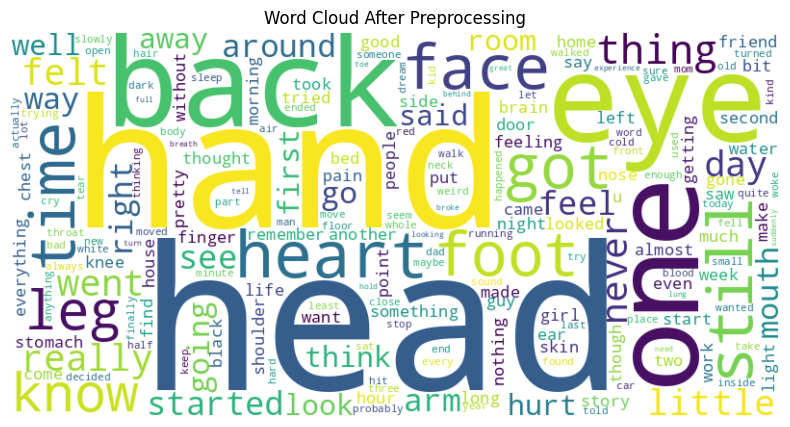

In [54]:
raw_text = ' '.join(df_train['processed_text'])
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud After Preprocessing')
plt.show()

# Saving Datasets (Stop words removed and lemmatization performed)

In [55]:
df_train.to_csv('../data/train_lemmastop.csv', index=False)
df_test.to_csv('../data/test_lemmastop.csv', index=False)